# 07 – EC3D One-Shot Retrieval: Pose → Pose

**Obiettivo**: Valutare le performance one-shot del pose encoder pre-addestrato (su FLAG3D) nella retrieval Pose→Pose su EC3D.

## Approccio One-Shot:

1. **Support Set** (1 esempio per classe): Selezioniamo una sequenza per ciascuna delle 12 classi di EC3D dal training set e ne calcoliamo l'embedding.

2. **Query**: Per ogni sample nella validation/test set, calcoliamo l'embedding della pose e lo confrontiamo con gli embeddings del support set.

3. **Classificazione via similarità**: Il sample viene classificato in base al nearest neighbor nel support set (cosine similarity).

## Vantaggi:
- Nessuna modifica architetturale: il dual encoder già proietta tutto in uno spazio condiviso
- Robustezza alla scarsità: utile per testare generalizzazione con pochi esempi
- Confrontabile con few-shot training classico

## Metriche:
- Accuracy Top-1, Top-5
- Confusion Matrix
- Analisi per classe

In [1]:
import sys
from pathlib import Path
import pickle
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

# Aggiungi root al path
ROOT_DIR = Path("..").resolve()
sys.path.insert(0, str(ROOT_DIR))
print(f"ROOT_DIR: {ROOT_DIR}")

from pose_encoder.twostream_stgcn_plus import TwoStreamSTGCNPlusEncoder

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Seed per riproducibilità
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

ROOT_DIR: /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/models
Using device: cuda


## 1. Configurazione e Path

In [2]:
# === PATH ===
DATA_DIR = ROOT_DIR.parent / "data" / "EC3D"
LOGS_DIR = ROOT_DIR.parent / "logs"
OUTPUT_DIR = ROOT_DIR.parent / "debug_outputs" / "ec3d_one_shot"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Checkpoint migliore
with open(LOGS_DIR / "best_epoch.txt", "r") as f:
    BEST_EPOCH = int(f.read().strip())
print(f"📌 Best epoch: {BEST_EPOCH}")

# === MAPPING CLASSI EC3D ===
ID_TO_NAME = {
    0: "SQUAT - Correct",
    1: "SQUAT - Feet too wide",
    2: "SQUAT - Knees inward",
    3: "SQUAT - Not deep enough",
    4: "SQUAT - Torso leaning forward",
    5: "SQUAT - Unknown error",
    6: "LUNGES - Correct",
    7: "LUNGES - Not deep enough",
    8: "LUNGES - Knees passing toes",
    9: "PLANK - Correct",
    10: "PLANK - Banana back",
    11: "PLANK - Rolled back"
}

SHORT_NAMES = {
    0: "SQ-OK", 1: "SQ-Wide", 2: "SQ-Knee", 3: "SQ-Shallow",
    4: "SQ-Lean", 5: "SQ-Unk", 6: "LU-OK", 7: "LU-Shallow",
    8: "LU-Knee", 9: "PL-OK", 10: "PL-Banana", 11: "PL-Roll"
}

print(f"\n📊 {len(ID_TO_NAME)} classi EC3D")

📌 Best epoch: 30

📊 12 classi EC3D


## 2. Caricamento Dataset EC3D

In [3]:
# Carica sequenze
with open(DATA_DIR / "ec3d_sequences.pkl", "rb") as f:
    ec3d_data = pickle.load(f)

# Carica split cross-subject
with open(DATA_DIR / "split_cross_subject.json", "r") as f:
    split = json.load(f)

sequences = ec3d_data["sequences"]  # lista di np.array (T, 3, 25)
labels = np.array(ec3d_data["labels"])  # np.array (N_seq,)

train_indices = np.array(split["train_indices"])
test_indices = np.array(split["test_indices"])

print(f"\n📥 Dataset EC3D caricato:")
print(f"   Totale sequenze: {len(sequences)}")
print(f"   Training set: {len(train_indices)} sequenze")
print(f"   Test set: {len(test_indices)} sequenze")
print(f"   Numero classi: {len(np.unique(labels))}")
print(f"   Esempio shape sequenza: {sequences[0].shape}")

# Distribuzione classi
train_labels = labels[train_indices]
test_labels = labels[test_indices]

print(f"\n📊 Distribuzione classi (training set):")
for cid in range(12):
    count = np.sum(train_labels == cid)
    print(f"   [{cid:2d}] {SHORT_NAMES[cid]:12s}: {count} samples")

print(f"\n📊 Distribuzione classi (test set):")
for cid in range(12):
    count = np.sum(test_labels == cid)
    print(f"   [{cid:2d}] {SHORT_NAMES[cid]:12s}: {count} samples")


📥 Dataset EC3D caricato:
   Totale sequenze: 371
   Training set: 283 sequenze
   Test set: 88 sequenze
   Numero classi: 12
   Esempio shape sequenza: (64, 3, 25)

📊 Distribuzione classi (training set):
   [ 0] SQ-OK       : 31 samples
   [ 1] SQ-Wide     : 18 samples
   [ 2] SQ-Knee     : 18 samples
   [ 3] SQ-Shallow  : 17 samples
   [ 4] SQ-Lean     : 17 samples
   [ 5] SQ-Unk      : 9 samples
   [ 6] LU-OK       : 34 samples
   [ 7] LU-Shallow  : 30 samples
   [ 8] LU-Knee     : 31 samples
   [ 9] PL-OK       : 26 samples
   [10] PL-Banana   : 21 samples
   [11] PL-Roll     : 31 samples

📊 Distribuzione classi (test set):
   [ 0] SQ-OK       : 10 samples
   [ 1] SQ-Wide     : 5 samples
   [ 2] SQ-Knee     : 5 samples
   [ 3] SQ-Shallow  : 4 samples
   [ 4] SQ-Lean     : 7 samples
   [ 5] SQ-Unk      : 0 samples
   [ 6] LU-OK       : 12 samples
   [ 7] LU-Shallow  : 10 samples
   [ 8] LU-Knee     : 10 samples
   [ 9] PL-OK       : 7 samples
   [10] PL-Banana   : 9 samples
   [11] 

## 3. Caricamento Pose Encoder Pre-addestrato

In [4]:
# === CARICA POSE ENCODER ===
print(f"\n📦 Caricamento Pose Encoder (epoch {BEST_EPOCH})...")
pose_encoder = TwoStreamSTGCNPlusEncoder(
    input_dim=3,
    hidden_channels=[64, 128, 256, 256],
    output_dim=128,
    num_nodes=25,
    dropout=0.1,
    fusion_dropout=0.3
)

pose_ckpt = torch.load(LOGS_DIR / f"pose_encoder_epoch{BEST_EPOCH}.pt", map_location=device)
pose_encoder.load_state_dict(pose_ckpt)
pose_encoder.to(device)
pose_encoder.eval()
print(f"   ✅ Pose encoder caricato")


📦 Caricamento Pose Encoder (epoch 30)...
   ✅ Pose encoder caricato


## 4. Funzioni di Encoding

In [5]:
def encode_pose_single(pose_encoder, sequence, device, max_len=150):
    """
    Codifica una singola sequenza di pose in embedding.
    
    Args:
        sequence: np.array (T, 3, 25)
        max_len: lunghezza massima per padding/truncation
    
    Returns:
        np.ndarray: (D,) embedding normalizzato L2
    """
    # Trasposizione: (T, 3, 25) -> (T, 25, 3)
    seq = np.transpose(sequence, (0, 2, 1))
    T, V, C = seq.shape
    
    # Padding/Truncation
    if T < max_len:
        pad = np.zeros((max_len - T, V, C), dtype=np.float32)
        seq = np.concatenate([seq, pad], axis=0)
    elif T > max_len:
        # Uniform sampling
        sample_indices = np.linspace(0, T - 1, max_len).astype(int)
        seq = seq[sample_indices]
    
    # Converti in tensor
    seq_tensor = torch.from_numpy(seq.astype(np.float32)).unsqueeze(0).to(device)
    
    with torch.no_grad():
        emb = pose_encoder(seq_tensor)  # (1, D)
        emb = F.normalize(emb, p=2, dim=1)  # L2 normalization
        return emb.squeeze(0).cpu().numpy()


def encode_poses(pose_encoder, sequences, indices, device, max_len=150):
    """
    Codifica le sequenze di pose in embedding.
    
    Args:
        sequences: lista di array (T, 3, 25)
        indices: indici delle sequenze da codificare
        max_len: lunghezza massima per padding/truncation
    
    Returns:
        np.ndarray: (N, D) array di embedding normalizzati L2
    """
    embeddings = []
    
    for idx in tqdm(indices, desc="Encoding poses"):
        emb = encode_pose_single(pose_encoder, sequences[idx], device, max_len)
        embeddings.append(emb)
    
    return np.vstack(embeddings)

## 5. Creazione Support Set (1 esempio per classe)

In [6]:
def create_support_set(sequences, labels, train_indices, num_classes=12, seed=42):
    """
    Seleziona 1 esempio per classe dal training set come support set.
    
    Returns:
        support_indices: lista di indici (uno per classe)
        support_labels: np.array delle label corrispondenti
    """
    np.random.seed(seed)
    random.seed(seed)
    
    support_indices = []
    support_labels = []
    
    for class_id in range(num_classes):
        # Trova tutti gli indici di training per questa classe
        class_mask = labels[train_indices] == class_id
        class_train_indices = train_indices[class_mask]
        
        if len(class_train_indices) > 0:
            # Seleziona un esempio casuale
            selected_idx = np.random.choice(class_train_indices)
            support_indices.append(selected_idx)
            support_labels.append(class_id)
            print(f"   [{class_id:2d}] {SHORT_NAMES[class_id]:12s}: selezionato indice {selected_idx}")
        else:
            print(f"   [{class_id:2d}] {SHORT_NAMES[class_id]:12s}: ⚠️ NESSUN ESEMPIO NEL TRAINING SET")
    
    return support_indices, np.array(support_labels)


print("\n🎯 Creazione Support Set (1 esempio per classe):")
support_indices, support_labels = create_support_set(sequences, labels, train_indices, seed=SEED)
print(f"\n✅ Support set creato: {len(support_indices)} esempi")


🎯 Creazione Support Set (1 esempio per classe):
   [ 0] SQ-OK       : selezionato indice 236
   [ 1] SQ-Wide     : selezionato indice 311
   [ 2] SQ-Knee     : selezionato indice 283
   [ 3] SQ-Shallow  : selezionato indice 288
   [ 4] SQ-Lean     : selezionato indice 294
   [ 5] SQ-Unk      : selezionato indice 333
   [ 6] LU-OK       : selezionato indice 42
   [ 7] LU-Shallow  : selezionato indice 43
   [ 8] LU-Knee     : selezionato indice 53
   [ 9] PL-OK       : selezionato indice 180
   [10] PL-Banana   : selezionato indice 193
   [11] PL-Roll     : selezionato indice 142

✅ Support set creato: 12 esempi


In [7]:
# Encoding del support set
print("\n🏃 Encoding support set...")
support_embeddings = encode_poses(pose_encoder, sequences, support_indices, device, max_len=150)
print(f"   Shape: {support_embeddings.shape}")


🏃 Encoding support set...


Encoding poses:   0%|          | 0/12 [00:00<?, ?it/s]

   Shape: (12, 128)


## 6. Encoding Test Set

In [8]:
# Codifica tutte le pose del test set
print("\n🏃 Encoding pose del test set...")
test_embeddings = encode_poses(pose_encoder, sequences, test_indices, device, max_len=150)
print(f"   Shape: {test_embeddings.shape}")


🏃 Encoding pose del test set...


Encoding poses:   0%|          | 0/88 [00:00<?, ?it/s]

   Shape: (88, 128)


## 7. One-Shot Retrieval

In [9]:
def one_shot_retrieval(query_embeddings, support_embeddings, support_labels):
    """
    Esegue one-shot retrieval: per ogni query, trova il nearest neighbor nel support set.
    
    Args:
        query_embeddings: (N_query, D) embeddings delle query
        support_embeddings: (N_support, D) embeddings del support set
        support_labels: (N_support,) label del support set
    
    Returns:
        predictions: (N_query,) label predette
        similarities: (N_query, N_support) matrice di similarità
    """
    # Calcola similarità coseno
    similarities = cosine_similarity(query_embeddings, support_embeddings)
    
    # Per ogni query, trova l'indice con massima similarità
    best_indices = np.argmax(similarities, axis=1)
    
    # Mappa agli label
    predictions = support_labels[best_indices]
    
    return predictions, similarities


# Esegui one-shot retrieval
print("\n🔍 Esecuzione One-Shot Retrieval...")
predictions, similarities = one_shot_retrieval(test_embeddings, support_embeddings, support_labels)

# Calcola accuracy
accuracy = accuracy_score(test_labels, predictions)
print(f"\n🎯 One-Shot Classification Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")


🔍 Esecuzione One-Shot Retrieval...

🎯 One-Shot Classification Accuracy: 0.4773 (47.7%)


## 8. Metriche di Valutazione

In [10]:
def compute_retrieval_metrics(similarities, ground_truth_labels, support_labels):
    """
    Calcola metriche di retrieval Pose → Pose.
    
    Args:
        similarities: (N_samples, N_support) matrice di similarità
        ground_truth_labels: (N_samples,) label veri
        support_labels: (N_support,) label del support set
    
    Returns:
        dict con metriche aggregate
    """
    N = len(ground_truth_labels)
    num_classes = len(support_labels)
    
    # Ranking per ogni sample (indici ordinati per similarità decrescente)
    rankings = np.argsort(-similarities, axis=1)
    
    # Mappa rankings agli label
    ranked_labels = support_labels[rankings]
    
    # Predictions top-1
    top1_preds = ranked_labels[:, 0]
    
    # Recall@1 (= Accuracy per one-shot)
    recall_at_1 = np.mean(top1_preds == ground_truth_labels)
    
    # Recall@3
    recall_at_3 = np.mean([gt in ranked_labels[i, :3] for i, gt in enumerate(ground_truth_labels)])
    
    # Recall@5
    recall_at_5 = np.mean([gt in ranked_labels[i, :5] for i, gt in enumerate(ground_truth_labels)])
    
    # Mean Reciprocal Rank (MRR)
    reciprocal_ranks = []
    for i, gt in enumerate(ground_truth_labels):
        rank_positions = np.where(ranked_labels[i] == gt)[0]
        if len(rank_positions) > 0:
            rank = rank_positions[0] + 1  # 1-indexed
            reciprocal_ranks.append(1.0 / rank)
        else:
            reciprocal_ranks.append(0.0)
    mrr = np.mean(reciprocal_ranks)
    
    # Per-class accuracy
    per_class_acc = {}
    for cid in range(num_classes):
        mask = ground_truth_labels == cid
        if np.sum(mask) > 0:
            per_class_acc[cid] = np.mean(top1_preds[mask] == cid)
        else:
            per_class_acc[cid] = 0.0
    
    return {
        'accuracy': recall_at_1,
        'recall@1': recall_at_1,
        'recall@3': recall_at_3,
        'recall@5': recall_at_5,
        'mrr': mrr,
        'per_class_acc': per_class_acc,
        'predictions': top1_preds,
        'rankings': rankings,
        'similarities': similarities
    }


# Calcola metriche complete
metrics = compute_retrieval_metrics(similarities, test_labels, support_labels)

print("\n" + "="*60)
print("🎯 ONE-SHOT RETRIEVAL RESULTS (Pose → Pose)")
print("="*60)
print(f"   Accuracy (Recall@1):  {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.1f}%)")
print(f"   Recall@3:             {metrics['recall@3']:.4f} ({metrics['recall@3']*100:.1f}%)")
print(f"   Recall@5:             {metrics['recall@5']:.4f} ({metrics['recall@5']*100:.1f}%)")
print(f"   MRR:                  {metrics['mrr']:.4f}")


🎯 ONE-SHOT RETRIEVAL RESULTS (Pose → Pose)
   Accuracy (Recall@1):  0.4773 (47.7%)
   Recall@3:             0.8068 (80.7%)
   Recall@5:             0.9545 (95.5%)
   MRR:                  0.6617


In [11]:
# Per-class accuracy
print("\n📊 Accuracy per classe:")
for cid, acc in metrics['per_class_acc'].items():
    count = np.sum(test_labels == cid)
    print(f"   [{cid:2d}] {SHORT_NAMES[cid]:12s}: {acc:.2%} ({int(acc * count)}/{count} corretti)")


📊 Accuracy per classe:
   [ 0] SQ-OK       : 100.00% (10/10 corretti)
   [ 1] SQ-Wide     : 0.00% (0/5 corretti)
   [ 2] SQ-Knee     : 0.00% (0/5 corretti)
   [ 3] SQ-Shallow  : 0.00% (0/4 corretti)
   [ 4] SQ-Lean     : 0.00% (0/7 corretti)
   [ 5] SQ-Unk      : 0.00% (0/0 corretti)
   [ 6] LU-OK       : 58.33% (7/12 corretti)
   [ 7] LU-Shallow  : 90.00% (9/10 corretti)
   [ 8] LU-Knee     : 70.00% (7/10 corretti)
   [ 9] PL-OK       : 0.00% (0/7 corretti)
   [10] PL-Banana   : 100.00% (9/9 corretti)
   [11] PL-Roll     : 0.00% (0/9 corretti)


## 9. Classification Report

In [12]:
# Classification report completo
print("\n📋 Classification Report:")
print(classification_report(
    test_labels, 
    predictions, 
    labels=list(range(12)),
    target_names=[SHORT_NAMES[i] for i in range(12)],
    zero_division=0
))


📋 Classification Report:
              precision    recall  f1-score   support

       SQ-OK       0.45      1.00      0.62        10
     SQ-Wide       0.00      0.00      0.00         5
     SQ-Knee       0.00      0.00      0.00         5
  SQ-Shallow       0.00      0.00      0.00         4
     SQ-Lean       0.00      0.00      0.00         7
      SQ-Unk       0.00      0.00      0.00         0
       LU-OK       0.70      0.58      0.64        12
  LU-Shallow       0.75      0.90      0.82        10
     LU-Knee       0.58      0.70      0.64        10
       PL-OK       0.00      0.00      0.00         7
   PL-Banana       0.50      1.00      0.67         9
     PL-Roll       0.00      0.00      0.00         9

    accuracy                           0.48        88
   macro avg       0.25      0.35      0.28        88
weighted avg       0.35      0.48      0.39        88



## 10. Confusion Matrix

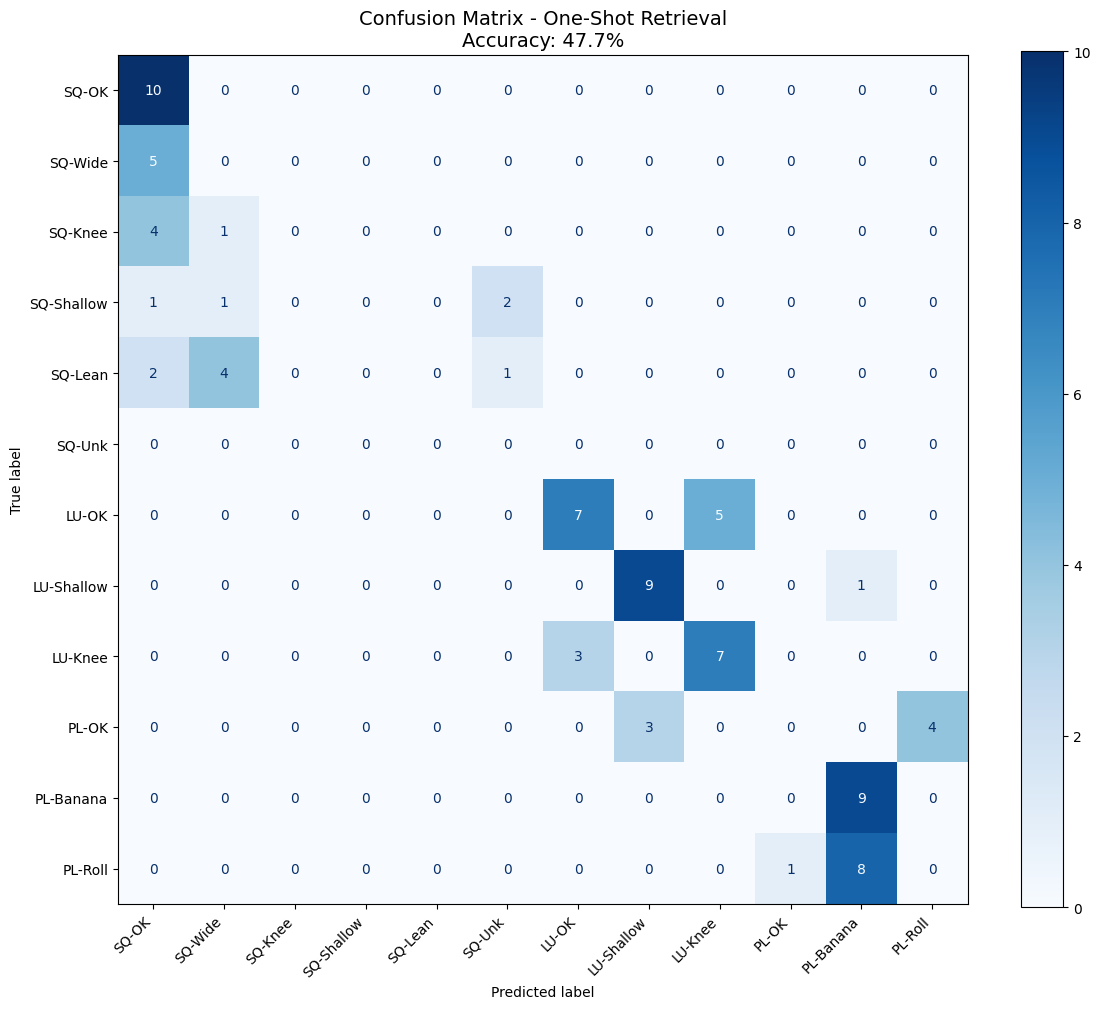

💾 Salvato in /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_one_shot/confusion_matrix_one_shot.png


In [13]:
# Confusion matrix
cm = confusion_matrix(test_labels, predictions, labels=list(range(12)))

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(cm, display_labels=[SHORT_NAMES[i] for i in range(12)])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix - One-Shot Retrieval\nAccuracy: {metrics["accuracy"]*100:.1f}%', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_one_shot.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Salvato in {OUTPUT_DIR / 'confusion_matrix_one_shot.png'}")

## 11. Analisi Distribuzione Similarità

/tmp/ipykernel_55731/1824013934.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([sims for _, sims in valid_classes], labels=[SHORT_NAMES[i] for i, _ in valid_classes])


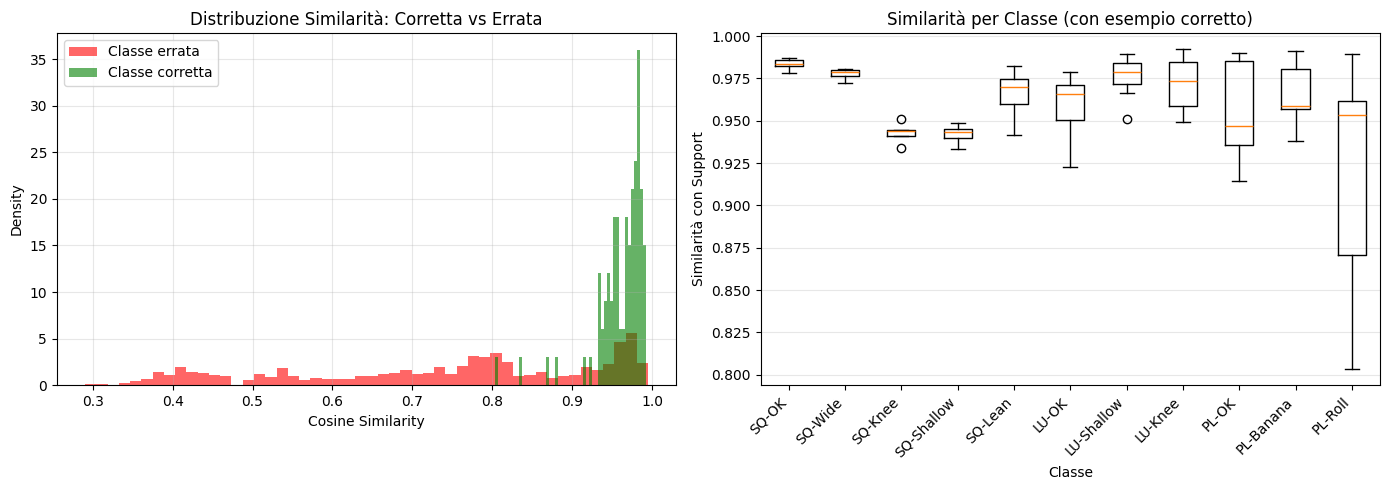

💾 Salvato in /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_one_shot/similarity_distributions_one_shot.png


In [14]:
# Analisi della distribuzione delle similarità
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Similarità con la classe corretta vs altre
correct_sims = []
incorrect_sims = []

for i, gt in enumerate(test_labels):
    # Trova l'indice nel support set per questa classe
    support_idx = np.where(support_labels == gt)[0]
    if len(support_idx) > 0:
        correct_sims.append(similarities[i, support_idx[0]])
    
    for j, sl in enumerate(support_labels):
        if sl != gt:
            incorrect_sims.append(similarities[i, j])

ax1 = axes[0]
ax1.hist(incorrect_sims, bins=50, alpha=0.6, label='Classe errata', color='red', density=True)
ax1.hist(correct_sims, bins=50, alpha=0.6, label='Classe corretta', color='green', density=True)
ax1.set_xlabel('Cosine Similarity')
ax1.set_ylabel('Density')
ax1.set_title('Distribuzione Similarità: Corretta vs Errata')
ax1.legend()
ax1.grid(alpha=0.3)

# Boxplot per classe
ax2 = axes[1]
per_class_sims = []
for cid in range(12):
    mask = test_labels == cid
    if np.sum(mask) > 0:
        support_idx = np.where(support_labels == cid)[0]
        if len(support_idx) > 0:
            class_sims = similarities[mask, support_idx[0]]
            per_class_sims.append(class_sims)
        else:
            per_class_sims.append([])
    else:
        per_class_sims.append([])

# Filtra classi vuote per il boxplot
valid_classes = [(i, sims) for i, sims in enumerate(per_class_sims) if len(sims) > 0]
if valid_classes:
    bp = ax2.boxplot([sims for _, sims in valid_classes], labels=[SHORT_NAMES[i] for i, _ in valid_classes])
    ax2.set_xlabel('Classe')
    ax2.set_ylabel('Similarità con Support')
    ax2.set_title('Similarità per Classe (con esempio corretto)')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "similarity_distributions_one_shot.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Salvato in {OUTPUT_DIR / 'similarity_distributions_one_shot.png'}")

## 12. Analisi Errori

In [15]:
# Analisi degli errori
errors_mask = predictions != test_labels
error_indices = np.where(errors_mask)[0]

print(f"\n❌ Analisi Errori One-Shot:")
print(f"   Totale errori: {len(error_indices)}/{len(test_labels)} ({len(error_indices)/len(test_labels)*100:.1f}%)")

# Coppie di confusione più frequenti
confusion_pairs = {}
for idx in error_indices:
    gt = test_labels[idx]
    pred = predictions[idx]
    pair = (ID_TO_NAME[gt], ID_TO_NAME[pred])
    confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

# Ordina per frequenza
sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)

print("\n🔄 Coppie di confusione più frequenti:")
for (gt, pred), count in sorted_pairs[:10]:
    print(f"   {gt} → {pred}: {count}")


❌ Analisi Errori One-Shot:
   Totale errori: 46/88 (52.3%)

🔄 Coppie di confusione più frequenti:
   PLANK - Rolled back → PLANK - Banana back: 8
   LUNGES - Correct → LUNGES - Knees passing toes: 5
   SQUAT - Feet too wide → SQUAT - Correct: 5
   PLANK - Correct → PLANK - Rolled back: 4
   SQUAT - Knees inward → SQUAT - Correct: 4
   SQUAT - Torso leaning forward → SQUAT - Feet too wide: 4
   LUNGES - Knees passing toes → LUNGES - Correct: 3
   PLANK - Correct → LUNGES - Not deep enough: 3
   SQUAT - Not deep enough → SQUAT - Unknown error: 2
   SQUAT - Torso leaning forward → SQUAT - Correct: 2


In [16]:
# Heatmap delle confusioni per tipo di esercizio
exercise_types = {'SQUAT': [0,1,2,3,4,5], 'LUNGES': [6,7,8], 'PLANK': [9,10,11]}

print("\n📊 Confusione inter-esercizio vs intra-esercizio:")

inter_errors = 0  # Errori tra esercizi diversi
intra_errors = 0  # Errori dentro lo stesso esercizio

for idx in error_indices:
    gt = test_labels[idx]
    pred = predictions[idx]
    
    gt_type = None
    pred_type = None
    for ex_type, classes in exercise_types.items():
        if gt in classes:
            gt_type = ex_type
        if pred in classes:
            pred_type = ex_type
    
    if gt_type == pred_type:
        intra_errors += 1
    else:
        inter_errors += 1

total_errors = len(error_indices)
if total_errors > 0:
    print(f"   Errori intra-esercizio (stesso tipo): {intra_errors} ({intra_errors/total_errors*100:.1f}%)")
    print(f"   Errori inter-esercizio (tipo diverso): {inter_errors} ({inter_errors/total_errors*100:.1f}%)")
else:
    print("   Nessun errore! 🎉")


📊 Confusione inter-esercizio vs intra-esercizio:
   Errori intra-esercizio (stesso tipo): 42 (91.3%)
   Errori inter-esercizio (tipo diverso): 4 (8.7%)


## 13. Robustezza: Multiple Run con Support Set Diversi

In [17]:
# Esegui multiple run con support set diversi per valutare variabilità
N_RUNS = 10
accuracies = []

print(f"\n🔄 Valutazione robustezza con {N_RUNS} support set diversi...")

for run_seed in tqdm(range(N_RUNS)):
    # Crea support set con seed diverso (senza stampare)
    np.random.seed(run_seed)
    random.seed(run_seed)
    
    run_support_indices = []
    run_support_labels = []
    
    for class_id in range(12):
        class_mask = labels[train_indices] == class_id
        class_train_indices = train_indices[class_mask]
        
        if len(class_train_indices) > 0:
            selected_idx = np.random.choice(class_train_indices)
            run_support_indices.append(selected_idx)
            run_support_labels.append(class_id)
    
    run_support_labels = np.array(run_support_labels)
    
    # Encoding support set
    run_support_embeddings = []
    for idx in run_support_indices:
        emb = encode_pose_single(pose_encoder, sequences[idx], device, max_len=150)
        run_support_embeddings.append(emb)
    run_support_embeddings = np.vstack(run_support_embeddings)
    
    # One-shot retrieval
    run_predictions, _ = one_shot_retrieval(test_embeddings, run_support_embeddings, run_support_labels)
    run_accuracy = accuracy_score(test_labels, run_predictions)
    accuracies.append(run_accuracy)

accuracies = np.array(accuracies)
print(f"\n📊 Risultati su {N_RUNS} run:")
print(f"   Mean Accuracy: {accuracies.mean():.4f} ({accuracies.mean()*100:.1f}%)")
print(f"   Std Accuracy:  {accuracies.std():.4f} ({accuracies.std()*100:.1f}%)")
print(f"   Min Accuracy:  {accuracies.min():.4f} ({accuracies.min()*100:.1f}%)")
print(f"   Max Accuracy:  {accuracies.max():.4f} ({accuracies.max()*100:.1f}%)")


🔄 Valutazione robustezza con 10 support set diversi...


  0%|          | 0/10 [00:00<?, ?it/s]


📊 Risultati su 10 run:
   Mean Accuracy: 0.4352 (43.5%)
   Std Accuracy:  0.0593 (5.9%)
   Min Accuracy:  0.3182 (31.8%)
   Max Accuracy:  0.5114 (51.1%)


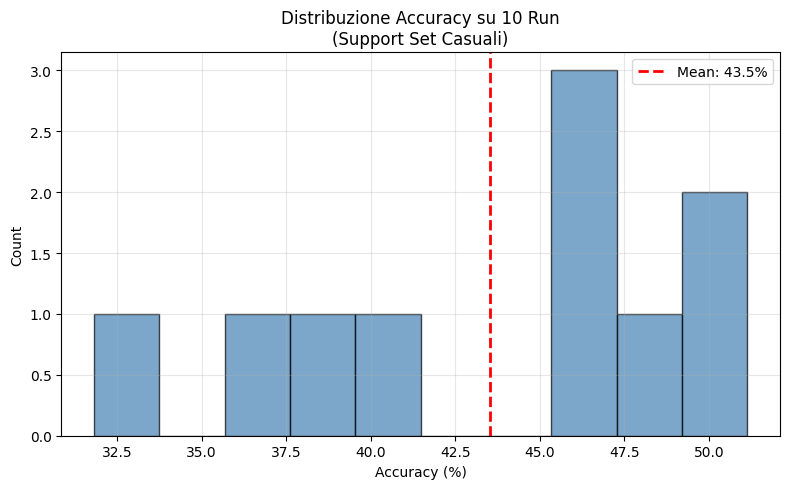

💾 Salvato in /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_one_shot/accuracy_distribution.png


In [18]:
# Visualizza distribuzione accuracy
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(accuracies * 100, bins=10, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(accuracies.mean() * 100, color='red', linestyle='--', linewidth=2, label=f'Mean: {accuracies.mean()*100:.1f}%')
ax.set_xlabel('Accuracy (%)')
ax.set_ylabel('Count')
ax.set_title(f'Distribuzione Accuracy su {N_RUNS} Run\n(Support Set Casuali)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Salvato in {OUTPUT_DIR / 'accuracy_distribution.png'}")

## 14. Confronto con Zero-Shot

In [19]:
# Carica risultati zero-shot se disponibili
zero_shot_path = OUTPUT_DIR.parent / "ec3d_zero_shot" / "zero_shot_results.json"

if zero_shot_path.exists():
    with open(zero_shot_path, 'r') as f:
        zero_shot_results = json.load(f)
    
    print("\n" + "="*70)
    print("📊 CONFRONTO: ONE-SHOT vs ZERO-SHOT")
    print("="*70)
    
    comparison_data = {
        'Metodo': [
            'One-Shot (Pose→Pose)', 
            f'One-Shot Mean ({N_RUNS} runs)',
            'Zero-Shot (Template)', 
            'Zero-Shot (FLAG3D Mean)'
        ],
        'Accuracy': [
            metrics['accuracy'],
            accuracies.mean(),
            zero_shot_results['template_generici']['recall@1'],
            zero_shot_results['flag3d_mean']['recall@1']
        ],
        'Recall@5': [
            metrics['recall@5'],
            '-',  # Non calcolato per multiple runs
            zero_shot_results['template_generici']['recall@5'],
            zero_shot_results['flag3d_mean']['recall@5']
        ],
        'MRR': [
            metrics['mrr'],
            '-',
            zero_shot_results['template_generici']['mrr'],
            zero_shot_results['flag3d_mean']['mrr']
        ]
    }
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    
    # Salva confronto
    comparison_df.to_csv(OUTPUT_DIR / "one_shot_vs_zero_shot.csv", index=False)
    print(f"\n💾 Salvato in {OUTPUT_DIR / 'one_shot_vs_zero_shot.csv'}")
else:
    print("\n⚠️ Risultati zero-shot non trovati. Esegui prima il notebook 06_ec3d_zero_shot_retrieval.ipynb")


📊 CONFRONTO: ONE-SHOT vs ZERO-SHOT
                 Metodo  Accuracy  Recall@5       MRR
   One-Shot (Pose→Pose)  0.477273  0.954545  0.661742
One-Shot Mean (10 runs)  0.435227         -         -
   Zero-Shot (Template)  0.000000  0.409091  0.192567
Zero-Shot (FLAG3D Mean)  0.000000  0.545455  0.244961

💾 Salvato in /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_one_shot/one_shot_vs_zero_shot.csv


## 15. Salvataggio Risultati

In [20]:
# Salva tutti i risultati
results = {
    'config': {
        'best_epoch': BEST_EPOCH,
        'test_samples': len(test_labels),
        'num_classes': 12,
        'seed': SEED,
        'n_runs_robustness': N_RUNS
    },
    'one_shot_single_run': {
        'accuracy': float(metrics['accuracy']),
        'recall@1': float(metrics['recall@1']),
        'recall@3': float(metrics['recall@3']),
        'recall@5': float(metrics['recall@5']),
        'mrr': float(metrics['mrr']),
        'per_class_acc': {int(k): float(v) for k, v in metrics['per_class_acc'].items()}
    },
    'robustness': {
        'mean_accuracy': float(accuracies.mean()),
        'std_accuracy': float(accuracies.std()),
        'min_accuracy': float(accuracies.min()),
        'max_accuracy': float(accuracies.max()),
        'all_accuracies': accuracies.tolist()
    },
    'support_set': {
        'indices': [int(i) for i in support_indices],
        'labels': support_labels.tolist()
    }
}

with open(OUTPUT_DIR / "one_shot_results.json", 'w') as f:
    json.dump(results, f, indent=2)

# Salva predizioni dettagliate
detailed_df = pd.DataFrame({
    'test_index': test_indices,
    'ground_truth': test_labels,
    'ground_truth_name': [ID_TO_NAME[l] for l in test_labels],
    'prediction': predictions,
    'prediction_name': [ID_TO_NAME[p] for p in predictions],
    'correct': predictions == test_labels,
    'similarity_to_correct': [similarities[i, np.where(support_labels == test_labels[i])[0][0]] 
                              if len(np.where(support_labels == test_labels[i])[0]) > 0 else 0 
                              for i in range(len(test_labels))]
})
detailed_df.to_csv(OUTPUT_DIR / "detailed_predictions.csv", index=False)

print(f"\n✅ Risultati salvati in {OUTPUT_DIR}:")
print("   - one_shot_results.json")
print("   - detailed_predictions.csv")
print("   - confusion_matrix_one_shot.png")
print("   - similarity_distributions_one_shot.png")
print("   - accuracy_distribution.png")
if zero_shot_path.exists():
    print("   - one_shot_vs_zero_shot.csv")


✅ Risultati salvati in /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_one_shot:
   - one_shot_results.json
   - detailed_predictions.csv
   - confusion_matrix_one_shot.png
   - similarity_distributions_one_shot.png
   - accuracy_distribution.png
   - one_shot_vs_zero_shot.csv


---

## 📋 Summary

Questo notebook valuta il pose encoder pre-addestrato su FLAG3D in uno scenario **one-shot** su EC3D.

### Approccio:
- **Support Set**: 1 esempio per classe dal training set
- **Retrieval**: Pose → Pose via cosine similarity
- **Classificazione**: Nearest Neighbor nel support set

### Vantaggi rispetto a Zero-Shot:
- Utilizza esempi reali invece di descrizioni testuali
- Non dipende dalla qualità delle annotazioni testuali
- Direttamente applicabile in scenari di few-shot learning

### Metriche calcolate:
- Accuracy (Recall@1), Recall@3, Recall@5, MRR
- Per-class accuracy
- Confusion matrix
- Robustezza su multiple run con support set diversi